# Benchmark Auswertung: Laptop 2
Static vs. Dynamic vs. Dynamic Adaptive

#### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import ast
from pathlib import Path
from scipy import stats

LAPTOP_ID      = 2
PROCESS_COUNTS = [1, 2, 4, 8]
IMAGE_COUNTS   = [100, 500, 1000]

colors  = {
    "Static":           "steelblue",
    "Dynamic":          "darkorange",
    "Dynamic Adaptive": "green"
}
markers = {
    "Static":           "o",
    "Dynamic":          "s",
    "Dynamic Adaptive": "^"
}

RESULTS_DIR = f"results/laptop{LAPTOP_ID}"
Path(RESULTS_DIR).mkdir(exist_ok=True)

#### 1. Daten laden

In [2]:
df_static  = pd.read_csv(f"{RESULTS_DIR}/results_static_laptop{LAPTOP_ID}.csv")
df_dynamic = pd.read_csv(f"{RESULTS_DIR}/results_dynamic_laptop{LAPTOP_ID}.csv")

df = pd.concat([df_static, df_dynamic], ignore_index=True)
df = df[df["Bilder"] != 5000]           # 5000er rausfiltern
df = df[df["Variante"] != "Dynamic True"] # Dynamic True rausfiltern

print(f"Zeilen gesamt: {len(df)}")
df.groupby(["Variante", "Datensatz"])["Bilder"].count()

Zeilen gesamt: 72


Variante          Datensatz       
Dynamic           Kaggle Pneumonia    12
                  NIH                 12
Dynamic Adaptive  Kaggle Pneumonia    12
                  NIH                 12
Static            Kaggle Pneumonia    12
                  NIH                 12
Name: Bilder, dtype: int64

#### 2. Laufzeit bei steigender Bildanzahl

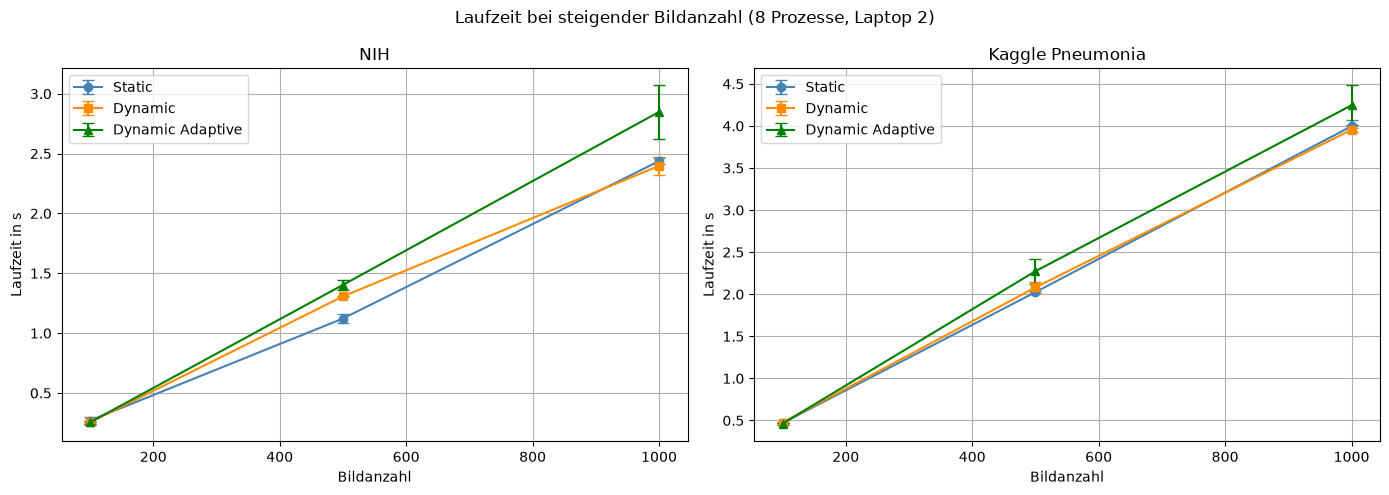

In [3]:
datasets = ["NIH", "Kaggle Pneumonia"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Laufzeit bei steigender Bildanzahl (8 Prozesse, Laptop {LAPTOP_ID})")

for ax, ds in zip(axes, datasets):
    for variant in ["Static", "Dynamic", "Dynamic Adaptive"]:
        sub = df[
            (df["Variante"]  == variant) &
            (df["Datensatz"] == ds) &
            (df["Prozesse"]  == 8)
        ]
        if not sub.empty:
            ax.errorbar(
                sub["Bilder"], sub["Laufzeit in s"],
                yerr=sub["Std"] if "Std" in sub.columns else None,
                color=colors[variant], marker=markers[variant],
                capsize=4, label=variant
            )
    ax.set_title(ds)
    ax.set_xlabel("Bildanzahl")
    ax.set_ylabel("Laufzeit in s")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/laufzeit_laptop{LAPTOP_ID}.png", dpi=150)
plt.show()

#### 3. Speedup

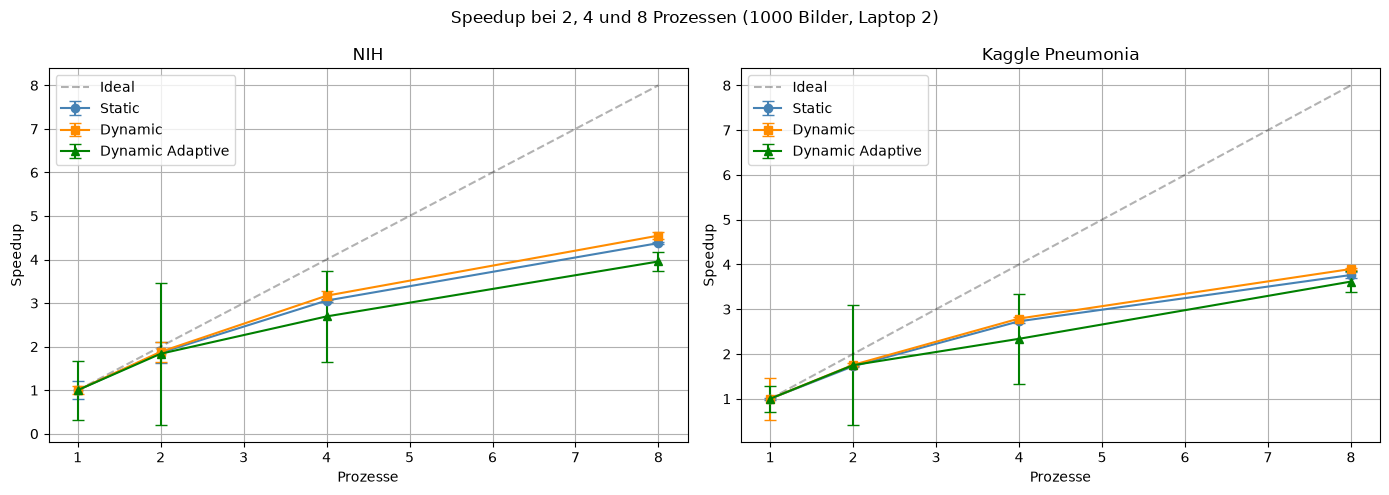

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Speedup bei 2, 4 und 8 Prozessen (1000 Bilder, Laptop {LAPTOP_ID})")

for ax, ds in zip(axes, datasets):
    for variant in ["Static", "Dynamic", "Dynamic Adaptive"]:
        sub = df[
            (df["Variante"]  == variant) &
            (df["Datensatz"] == ds) &
            (df["Bilder"]    == 1000)
        ]
        if not sub.empty:
            ax.errorbar(
                sub["Prozesse"], sub["Speedup"],
                yerr=sub["Std"] if "Std" in sub.columns else None,
                color=colors[variant], marker=markers[variant],
                capsize=4, label=variant
            )
    ax.plot(PROCESS_COUNTS, PROCESS_COUNTS, "k--", alpha=0.3, label="Ideal")
    ax.set_title(ds)
    ax.set_xlabel("Prozesse")
    ax.set_ylabel("Speedup")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/speedup_laptop{LAPTOP_ID}.png", dpi=150)
plt.show()

#### 4. Efficiency

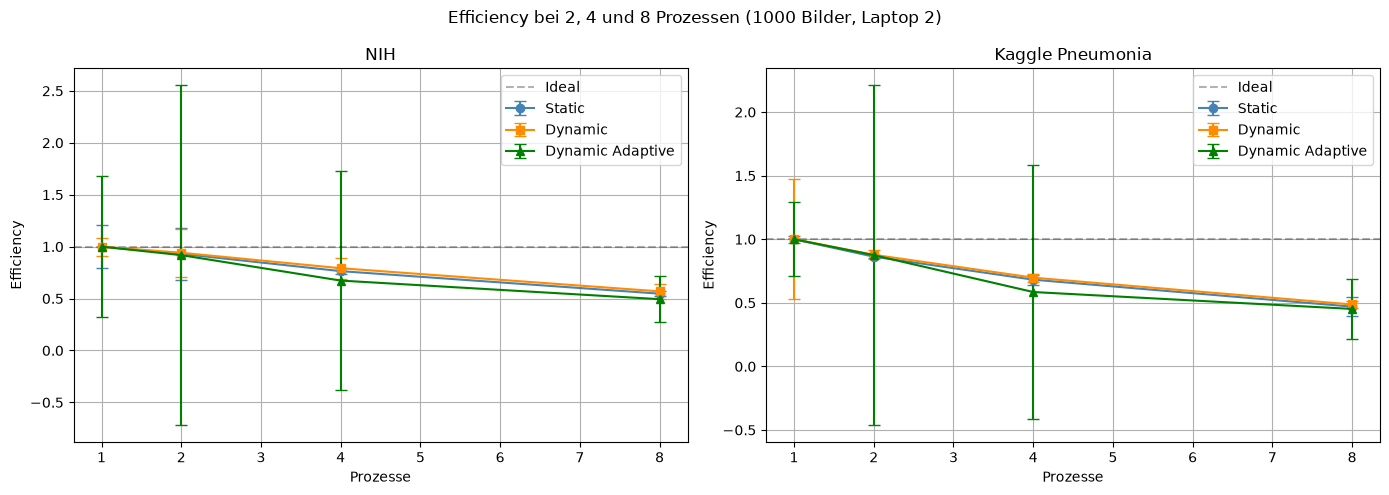

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Efficiency bei 2, 4 und 8 Prozessen (1000 Bilder, Laptop {LAPTOP_ID})")

for ax, ds in zip(axes, datasets):
    for variant in ["Static", "Dynamic", "Dynamic Adaptive"]:
        sub = df[
            (df["Variante"]  == variant) &
            (df["Datensatz"] == ds) &
            (df["Bilder"]    == 1000)
        ]
        if not sub.empty:
            ax.errorbar(
                sub["Prozesse"], sub["Efficiency"],
                yerr=sub["Std"] if "Std" in sub.columns else None,
                color=colors[variant], marker=markers[variant],
                capsize=4, label=variant
            )
    ax.axhline(1.0, color="k", linestyle="--", alpha=0.3, label="Ideal")
    ax.set_title(ds)
    ax.set_xlabel("Prozesse")
    ax.set_ylabel("Efficiency")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/efficiency_laptop{LAPTOP_ID}.png", dpi=150)
plt.show()

#### 5. Static vs. Dynamic vs. Dynamic Adaptive

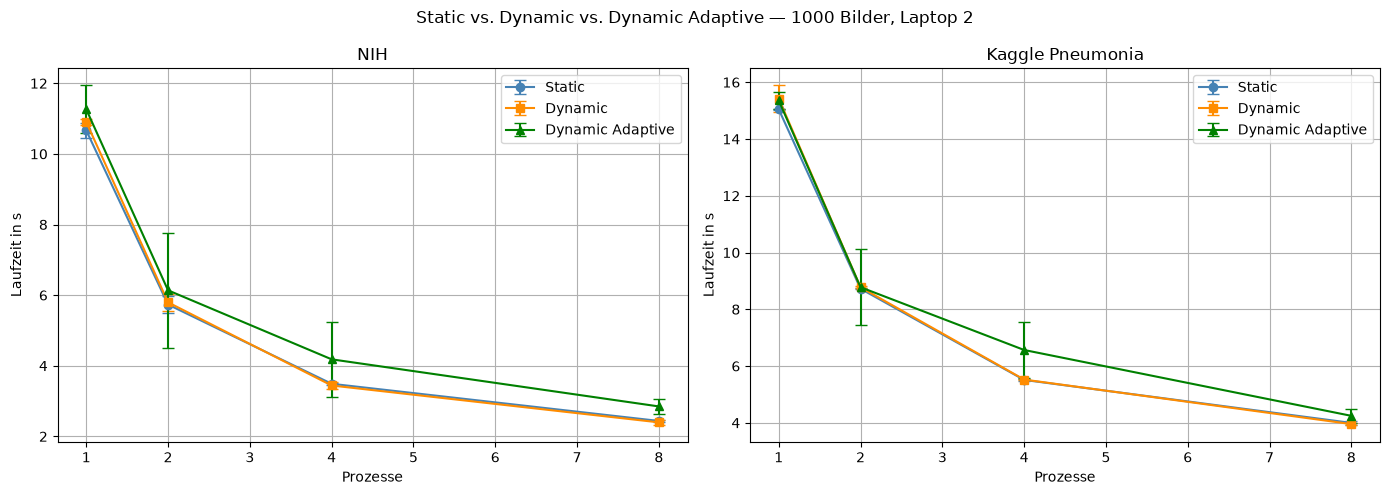

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Static vs. Dynamic vs. Dynamic Adaptive — 1000 Bilder, Laptop {LAPTOP_ID}")

for ax, ds in zip(axes, datasets):
    for variant in ["Static", "Dynamic", "Dynamic Adaptive"]:
        sub = df[
            (df["Variante"]  == variant) &
            (df["Datensatz"] == ds) &
            (df["Bilder"]    == 1000)
        ]
        if not sub.empty:
            ax.errorbar(
                sub["Prozesse"], sub["Laufzeit in s"],
                yerr=sub["Std"] if "Std" in sub.columns else None,
                color=colors[variant], marker=markers[variant],
                capsize=4, label=variant
            )
    ax.set_title(ds)
    ax.set_xlabel("Prozesse")
    ax.set_ylabel("Laufzeit in s")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/static_vs_dynamic_laptop{LAPTOP_ID}.png", dpi=150)
plt.show()

#### 6. Amdahls Gesetz

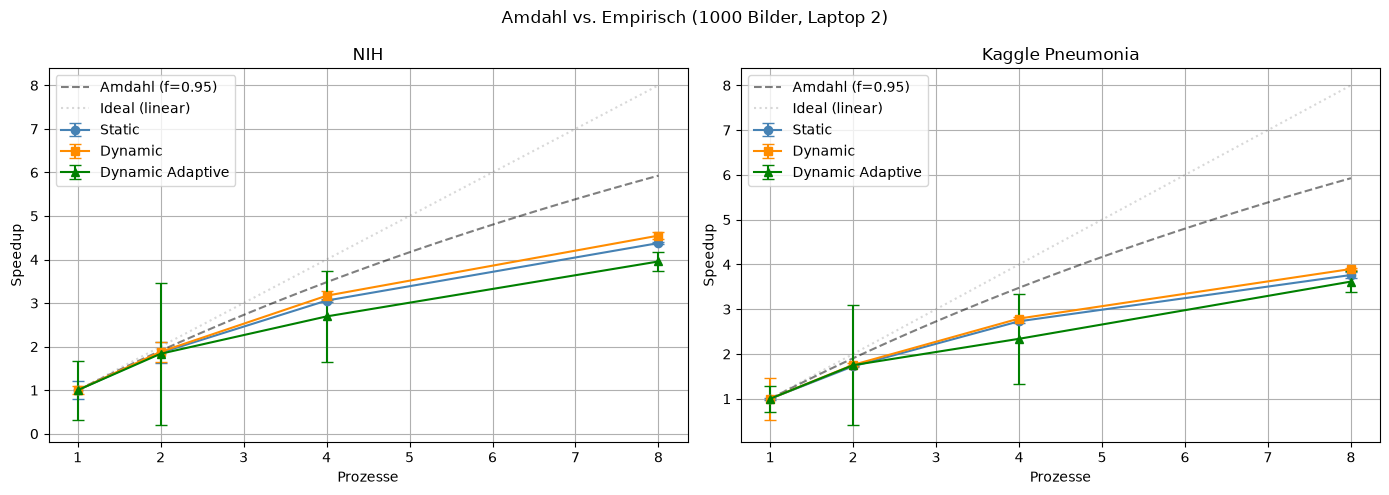

In [7]:
def amdahl(p, f=0.95):
    return 1 / ((1 - f) + f / p)

p_range = np.linspace(1, 8, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Amdahl vs. Empirisch (1000 Bilder, Laptop {LAPTOP_ID})")

for ax, ds in zip(axes, datasets):
    ax.plot(p_range, [amdahl(p) for p in p_range], "k--", alpha=0.5, label="Amdahl (f=0.95)")
    ax.plot(PROCESS_COUNTS, PROCESS_COUNTS, "gray", linestyle=":", alpha=0.3, label="Ideal (linear)")
    for variant in ["Static", "Dynamic", "Dynamic Adaptive"]:
        sub = df[
            (df["Variante"]  == variant) &
            (df["Datensatz"] == ds) &
            (df["Bilder"]    == 1000)
        ]
        if not sub.empty:
            ax.errorbar(
                sub["Prozesse"], sub["Speedup"],
                yerr=sub["Std"] if "Std" in sub.columns else None,
                color=colors[variant], marker=markers[variant],
                capsize=4, label=variant
            )
    ax.set_title(ds)
    ax.set_xlabel("Prozesse")
    ax.set_ylabel("Speedup")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/amdahl_laptop{LAPTOP_ID}.png", dpi=150)
plt.show()

#### 7. t-Test: Static vs. Dynamic vs. Dynamic Adaptive

In [8]:
def get_times(row):
    if row.empty or "all_times" not in row.columns:
        return None
    val = row["all_times"].values[0]
    if isinstance(val, float) and math.isnan(val):
        return None
    return ast.literal_eval(val)


results_ttest = []

for ds in datasets:
    for n_img in IMAGE_COUNTS:
        for n_proc in PROCESS_COUNTS:

            row_static = df[
                (df["Variante"]  == "Static") &
                (df["Datensatz"] == ds) &
                (df["Bilder"]    == n_img) &
                (df["Prozesse"]  == n_proc)
            ]
            row_dynamic = df[
                (df["Variante"]  == "Dynamic") &
                (df["Datensatz"] == ds) &
                (df["Bilder"]    == n_img) &
                (df["Prozesse"]  == n_proc)
            ]
            row_adaptive = df[
                (df["Variante"]  == "Dynamic Adaptive") &
                (df["Datensatz"] == ds) &
                (df["Bilder"]    == n_img) &
                (df["Prozesse"]  == n_proc)
            ]

            if row_static.empty or row_dynamic.empty or row_adaptive.empty:
                continue

            t_static   = get_times(row_static)
            t_dynamic  = get_times(row_dynamic)
            t_adaptive = get_times(row_adaptive)

            if t_static is None or t_dynamic is None or t_adaptive is None:
                continue

            _, p_static_dynamic   = stats.ttest_ind(t_static, t_dynamic)
            _, p_static_adaptive  = stats.ttest_ind(t_static, t_adaptive)
            _, p_dynamic_adaptive = stats.ttest_ind(t_dynamic, t_adaptive)

            results_ttest.append({
                "Datensatz":               ds,
                "Bilder":                  n_img,
                "Prozesse":                n_proc,
                "Static Median":           round(float(row_static["Laufzeit in s"].values[0]), 3),
                "Dynamic Median":          round(float(row_dynamic["Laufzeit in s"].values[0]), 3),
                "Adaptive Median":         round(float(row_adaptive["Laufzeit in s"].values[0]), 3),
                "p Static vs Dynamic":     round(p_static_dynamic, 4),
                "p Static vs Adaptive":    round(p_static_adaptive, 4),
                "p Dynamic vs Adaptive":   round(p_dynamic_adaptive, 4),
                "Static vs Dynamic sig.":  "ja" if p_static_dynamic  < 0.05 else "nein",
                "Static vs Adaptive sig.": "ja" if p_static_adaptive < 0.05 else "nein",
                "Dynamic vs Adaptive sig.":"ja" if p_dynamic_adaptive < 0.05 else "nein",
            })

df_ttest = pd.DataFrame(results_ttest)
print(df_ttest.to_markdown(index=False))

| Datensatz        |   Bilder |   Prozesse |   Static Median |   Dynamic Median |   Adaptive Median |   p Static vs Dynamic |   p Static vs Adaptive |   p Dynamic vs Adaptive | Static vs Dynamic sig.   | Static vs Adaptive sig.   | Dynamic vs Adaptive sig.   |
|:-----------------|---------:|-----------:|----------------:|-----------------:|------------------:|----------------------:|-----------------------:|------------------------:|:-------------------------|:--------------------------|:---------------------------|
| NIH              |      100 |          1 |           1.083 |            1.057 |             1.063 |                0.0594 |                 0.0666 |                  0.6036 | nein                     | nein                      | nein                       |
| NIH              |      100 |          2 |           0.593 |            0.557 |             0.585 |                0.0271 |                 0.2324 |                  0.0735 | ja                       | nein         

In [9]:
print(df.columns.tolist())
print("all_times" in df.columns)
print(df[df["Variante"] == "Static"]["all_times"].head())

['Laptop', 'Variante', 'Datensatz', 'Bilder', 'Prozesse', 'Laufzeit in s', 'Std', 'CI_low', 'CI_high', 'Speedup', 'Efficiency', 'Throughput', 'all_times']
True
0    [1.0502629920010804, 1.0564130210004805, 1.050...
1    [0.5592513360006706, 0.6320474940002896, 0.566...
2    [0.41707854400010547, 0.36236131700025, 0.3557...
3    [0.33532510500117496, 0.26195231399833574, 0.3...
4    [5.915830683999957, 5.368576483000652, 5.59627...
Name: all_times, dtype: str


#### 8. Ergebnistabelle

In [10]:
cols = ["Variante", "Datensatz", "Bilder", "Prozesse",
        "Laufzeit in s", "Speedup", "Efficiency", "Throughput"]

for col in ["Std", "CI_low", "CI_high"]:
    if col in df.columns:
        cols.append(col)

table = df[cols].sort_values(["Variante", "Datensatz", "Bilder", "Prozesse"])
print(table.to_markdown(index=False))

| Variante         | Datensatz        |   Bilder |   Prozesse |   Laufzeit in s |   Speedup |   Efficiency |   Throughput |    Std |   CI_low |   CI_high |
|:-----------------|:-----------------|---------:|-----------:|----------------:|----------:|-------------:|-------------:|-------:|---------:|----------:|
| Dynamic          | Kaggle Pneumonia |      100 |          1 |           1.549 |     1     |        1     |        64.54 | 0.0402 |   1.5207 |    1.5782 |
| Dynamic          | Kaggle Pneumonia |      100 |          2 |           0.926 |     1.673 |        0.837 |       107.96 | 0.0223 |   0.9104 |    0.9423 |
| Dynamic          | Kaggle Pneumonia |      100 |          4 |           0.619 |     2.502 |        0.625 |       161.65 | 0.0095 |   0.6118 |    0.6254 |
| Dynamic          | Kaggle Pneumonia |      100 |          8 |           0.475 |     3.261 |        0.408 |       210.64 | 0.0085 |   0.4686 |    0.4808 |
| Dynamic          | Kaggle Pneumonia |      500 |          1 | 